# Heart Disease Prediction Analysis

This notebook performs an exploratory data analysis and machine learning preparation on heart disease clinical data. The analysis aims to predict the presence or absence of heart disease using clinical features.

# Descargar CSV material

In [95]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("neurocipher/heartdisease")
os.mkdir("CSV")
destino = "CSV"
os.makedirs(destino, exist_ok=True)

for archivo in os.listdir(path):
    if archivo.endswith(".csv"):
        shutil.copy(
            os.path.join(path, archivo),
            os.path.join(destino, archivo)
        )

print("CSV copiados a:", os.path.abspath(destino))


CSV copiados a: c:\Users\Danie\Documents\TDSE\trabajo 2\CSV


## Step 0: Data Download and Setup

The code below downloads the Heart Disease dataset from Kaggle and copies it to a local CSV folder. It uses the kagglehub API to fetch the "neurocipher/heartdisease" dataset and organizes all CSV files into a dedicated directory for easy access. The output message confirms successful file transfer.

## Paso 1:

In [96]:
import pandas as pd

data = pd.read_csv(os.path.join(destino, "Heart_Disease_Prediction.csv"))
print(data.head())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2                        0   

### Load and Display Dataset

The Heart Disease dataset is loaded using pandas read_csv function. The dataset contains clinical patient records with medical measurements and diagnostic information. The `.head()` method displays the first 5 rows to preview the data structure, column names, and initial values.

# Binarizado 

In [97]:
data["Heart Disease"] = data["Heart Disease"].replace({
    "Absence": 0,
    "Presence": 1
})
print(data.head())


   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3             1  
1                        0         7             0  
2                        0   

### Binary Encoding of Target Variable

The "Heart Disease" column is converted from categorical values to binary numerical format using the replace method. The mapping converts "Absence" to 0 (no disease) and "Presence" to 1 (disease present). This binary encoding is essential for machine learning algorithms that require numerical input labels.

### The dataset contains clinical records of patients used to predict the presence of heart disease.

# EDA


In [98]:
data.shape


(270, 14)

## Exploratory Data Analysis (EDA)

### Dataset Dimensions

The `.shape` attribute returns the dimensions of the dataframe: the number of rows (samples/observations) and columns (features/variables). This result shows the total dataset size available for analysis.

In [99]:
data.columns


Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

### Column Names

The `.columns` attribute displays all the feature names in the dataset. This helps understand what medical measurements and patient attributes are included in the analysis (age, cholesterol, blood pressure, electrocardiogram results, etc.).

In [100]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), object(1)
m

### Data Information

The `.info()` method provides a comprehensive overview including the number of non-null entries in each column, data types (int, float, object), and memory usage. This helps identify missing values and data type conversions needed.

In [101]:
data["Heart Disease"].value_counts()


Heart Disease
0    150
1    120
Name: count, dtype: int64

### Target Variable Distribution

The `.value_counts()` method counts the occurrences of each unique value in the "Heart Disease" column. The output shows how many samples have disease absence (0) and disease presence (1), revealing class balance or imbalance in the dataset.

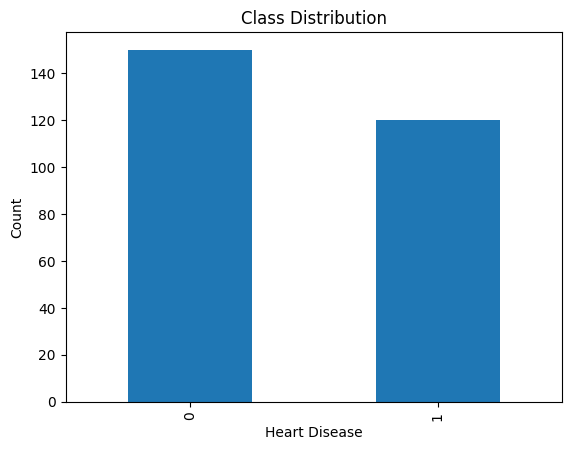

In [102]:
import matplotlib.pyplot as plt

data["Heart Disease"].value_counts().plot(kind="bar")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()


### Class Distribution Visualization

This bar chart visualizes the distribution of the target variable (Heart Disease). The x-axis shows the two classes (0=Absence, 1=Presence) and the y-axis shows the count of samples in each class. This visualization helps identify if there is a class imbalance that might affect model training.

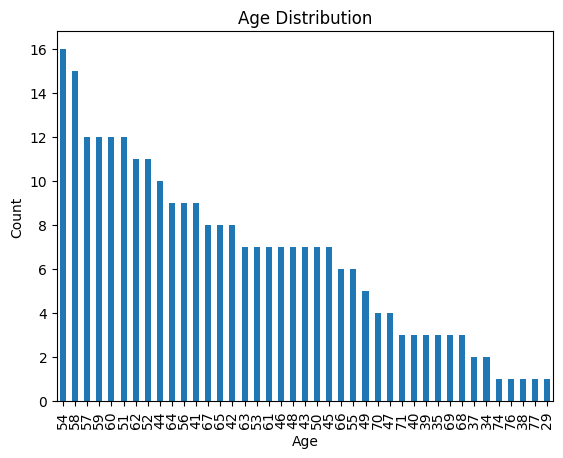

In [103]:
import matplotlib.pyplot as plt

data["Age"].value_counts().plot(kind="bar")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


### Age Distribution

This bar chart displays the distribution of patient ages in the dataset. The x-axis shows age values and the y-axis shows the frequency (count) of patients for each age. This reveals the age range and demographic composition of the study population, helping understand potential age-related patterns in heart disease.

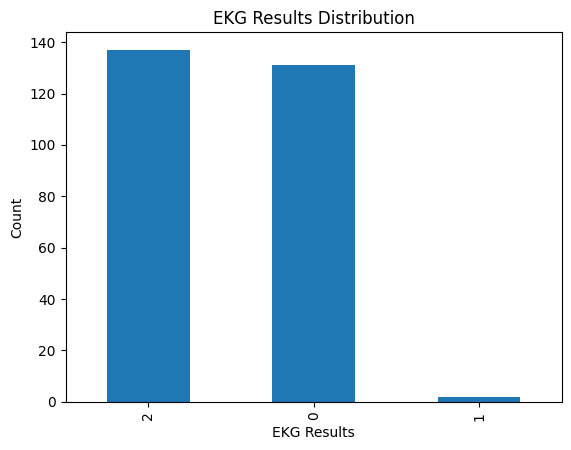

In [104]:
import matplotlib.pyplot as plt

data["EKG results"].value_counts().plot(kind="bar")
plt.xlabel("EKG Results")
plt.ylabel("Count")
plt.title("EKG Results Distribution")
plt.show()

### EKG Results Distribution

This bar chart shows the distribution of electrocardiogram (EKG) test results across the dataset. The x-axis represents different EKG result categories and the y-axis shows their frequency. EKG results are an important clinical indicator for diagnosing heart disease, so understanding their distribution is crucial for the analysis.

In [105]:
data.isnull().sum()


Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

### Missing Values Check

The `.isnull().sum()` method counts missing (null/NaN) values in each column. A result of zero across all columns indicates data completeness. This is important because missing values can affect model training and require imputation strategies if present.

In [106]:
data["Sex"].value_counts()
data["Chest pain type"].value_counts()


Chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64

### Categorical Features Analysis

The `.value_counts()` method is applied to "Sex" and "Chest pain type" columns to count occurrences of each category. Sex shows the gender distribution (male/female ratio) and chest pain type shows the frequency of different pain classifications, which are important clinical attributes for heart disease diagnosis.

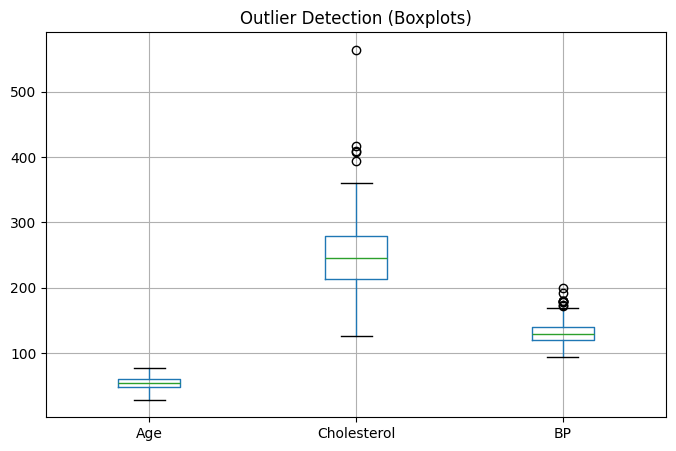

In [107]:
data[["Age", "Cholesterol", "BP"]].boxplot(figsize=(8,5))
plt.title("Outlier Detection (Boxplots)")
plt.show()


### Outlier Detection Using Boxplots

Boxplots are created for three numerical features: Age, Cholesterol, and Blood Pressure. These visualizations display the quartiles, median, and outliers (extreme values). Points beyond the whiskers indicate outliers that might represent unusual clinical measurements requiring further investigation or potential data quality issues.

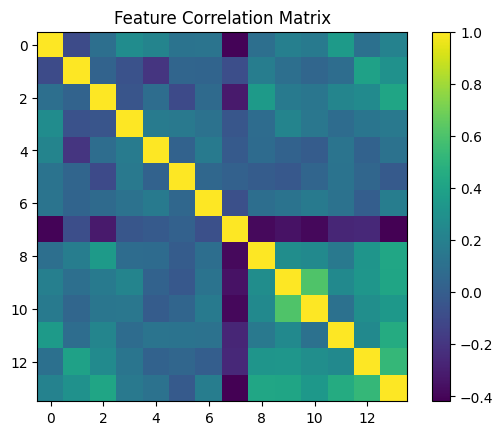

In [108]:
import numpy as np

corr = data.corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.show()


## Correlation Analysis

The feature correlation matrix is computed using `.corr()` which calculates the Pearson correlation coefficient between all numerical features. The heatmap visualization displays correlations as colors where darker shades represent stronger correlations (positive or negative). This helps identify which features are most related to each other and to the target variable, informing feature selection for modeling.

# PREP

In [109]:
# Target
y = data["Heart Disease"].values  

# Features
features = [
    "Age",
    "Cholesterol",
    "BP",
    "Max HR",
    "ST depression",
    "Number of vessels fluro"
]

X = data[features].values  
print("X shape:", X.size, ", y shape:", y.size)


X shape: 1620 , y shape: 270


## Data Preparation

### Feature and Target Extraction

The target variable `y` contains the "Heart Disease" binary values (0 or 1). The feature matrix `X` contains six selected clinical measurements: Age, Cholesterol, Blood Pressure (BP), Maximum Heart Rate (Max HR), ST segment depression, and Number of vessels visible on fluoroscopy. These features are extracted as numpy arrays for efficient numerical computation. The output shows the total number of samples and features being used for model training.

In [110]:
import numpy as np

np.random.seed(42)


idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

split_0 = int(0.7 * len(idx_0))
split_1 = int(0.7 * len(idx_1))

train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
test_idx  = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(X_train.shape, X_test.shape)


(189, 6) (81, 6)


### Stratified Train-Test Split

The dataset is split into training (70%) and testing (30%) sets while preserving the class distribution. The code separately identifies indices for each class (0 and 1), shuffles them independently, and splits each class proportionally. This stratification ensures both train and test sets have similar class balances, preventing skewed model evaluation. The output confirms the shapes of the resulting training and testing matrices.

In [111]:
m = X_train.shape[0]
m_test = X_test.shape[0]

X_train_matrix = np.c_[np.ones(m), X_train]
X_test_matrix = np.c_[np.ones(m_test), X_test]

### Feature Matrix Augmentation

A column of ones is prepended to the training feature matrix using `np.c_`. This creates an augmented matrix that includes a bias term (intercept) for linear regression models. The bias column allows the model to learn an offset independent of the input features, which is essential for accurate predictions.

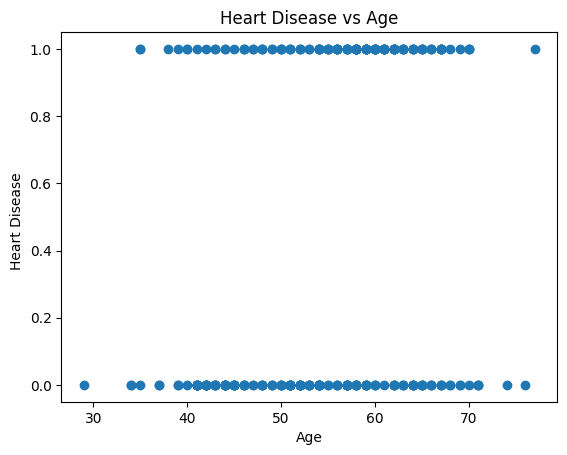

In [112]:

plt.figure()
plt.scatter(data["Age"], data["Heart Disease"])
plt.xlabel("Age")
plt.ylabel("Heart Disease  ")
plt.title("Heart Disease vs Age")
plt.show()

### Relationship Between Age and Heart Disease

This scatter plot visualizes the relationship between patient age (x-axis) and heart disease presence (y-axis). Each point represents a patient, with y=0 indicating no disease and y=1 indicating disease presence. This visualization helps identify potential age-related patterns and whether age is a discriminative feature for predicting heart disease in logistic regression models.

In [113]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [114]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    
    z = X @ w + b
    y_hat = sigmoid(z)
    
    # evitar log(0)
    eps = 1e-15
    cost = -(1/m) * np.sum(
        y * np.log(y_hat + eps) + 
        (1 - y) * np.log(1 - y_hat + eps)
    )
    return cost


In [115]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    
    z = X @ w + b
    y_hat = sigmoid(z)
    
    dz = y_hat - y
    dw = (1/m) * (X.T @ dz)
    dw = np.asarray(dw).flatten()  # Asegurar que sea 1D
    db = (1/m) * np.sum(dz)
    
    return dw, db

In [116]:
def gradient_descent(X, y, lr=0.01, n_iters=2000):
    m, n = X.shape
    w = np.zeros(n, dtype=np.float64)
    b = 0.0
    
    costs = []
    
    for i in range(n_iters):
        dw, db = compute_gradients(X, y, w, b)
        
        w -= lr * dw
        b -= lr * db
        
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)
            print(f"Iter {i}: Cost = {cost:.4f}")
    
    return w, b, costs

In [117]:
y_train = y_train.astype(np.float64)
y_test  = y_test.astype(np.float64)

print(X_train_matrix.dtype)  # float64
print(y_train.dtype)         # float64


float64
float64


In [118]:
w, b, costs = gradient_descent(
    X_train_matrix,
    y_train,
    lr=0.01,
    n_iters=3000
)

Iter 0: Cost = 15.3506
Iter 100: Cost = 15.3506
Iter 200: Cost = 13.8448
Iter 300: Cost = 13.4197
Iter 400: Cost = 13.3613
Iter 500: Cost = 13.4383
Iter 600: Cost = 13.4223
Iter 700: Cost = 13.3754
Iter 800: Cost = 13.3965
Iter 900: Cost = 13.4690
Iter 1000: Cost = 13.3970
Iter 1100: Cost = 13.3786
Iter 1200: Cost = 13.3777
Iter 1300: Cost = 13.3773
Iter 1400: Cost = 13.3772
Iter 1500: Cost = 13.3768
Iter 1600: Cost = 13.3766
Iter 1700: Cost = 13.3757
Iter 1800: Cost = 13.3758
Iter 1900: Cost = 13.3750
Iter 2000: Cost = 13.3742
Iter 2100: Cost = 13.3745
Iter 2200: Cost = 13.3737
Iter 2300: Cost = 13.3729
Iter 2400: Cost = 13.3721
Iter 2500: Cost = 13.3712
Iter 2600: Cost = 13.3704
Iter 2700: Cost = 13.3695
Iter 2800: Cost = 13.3686
Iter 2900: Cost = 13.3737


C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1702624272.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## Model Training

### Gradient Descent Optimization

The logistic regression model is trained using gradient descent optimization. The algorithm iteratively updates the weight vector `w` and bias term `b` by computing gradients from the training data and moving in the negative gradient direction. With 3000 iterations and a learning rate of 0.01, the model learns to minimize the binary cross-entropy loss function, gradually improving its ability to predict heart disease presence or absence.

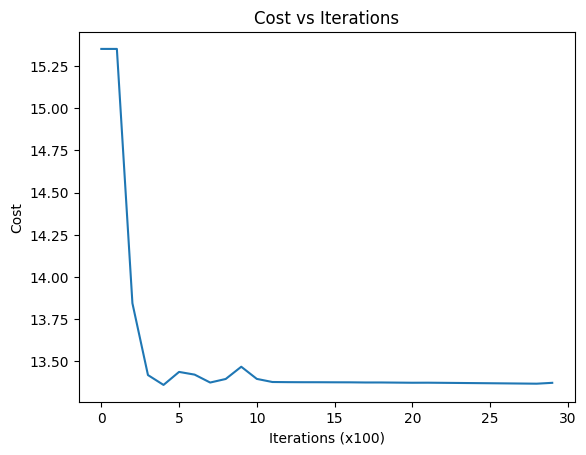

In [119]:
plt.figure()
plt.plot(costs)
plt.xlabel("Iterations (x100)")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()


### Cost Function Convergence

This line plot visualizes how the model's cost (loss) changes across training iterations. The x-axis represents iterations (in units of 100), and the y-axis shows the cost value. A decreasing cost curve indicates successful convergence of the optimization algorithm. The plot helps diagnose whether the learning rate is appropriate and if the model is learning effectively from the training data.

In [120]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)


## Model Evaluation

### Prediction Function

The `predict` function converts the model's probability output into binary class predictions (0 or 1) using a threshold of 0.5. For each input sample, it computes the sigmoid of the linear combination (X·w + b), which produces a probability between 0 and 1. Any probability >= 0.5 is classified as 1 (heart disease present), while probabilities < 0.5 are classified as 0 (heart disease absent).

In [121]:
def classification_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)
    f1 = 2 * precision * recall / (precision + recall + 1e-15)
    
    return accuracy, precision, recall, f1


### Classification Metrics

The `classification_metrics` function computes four key performance metrics from predictions:
- **Accuracy**: The proportion of correct predictions overall: (TP + TN) / Total
- **Precision**: Of predicted positive cases, how many were actually positive: TP / (TP + FP)
- **Recall**: Of actual positive cases, how many were correctly identified: TP / (TP + FN)
- **F1-Score**: The harmonic mean of precision and recall: 2·Precision·Recall / (Precision + Recall)

These metrics use true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) calculated from comparing predictions to true labels.

In [122]:
y_train_pred = predict(X_train_matrix, w, b)
y_test_pred = predict(X_test_matrix, w, b)

train_metrics = classification_metrics(y_train, y_train_pred)
test_metrics = classification_metrics(y_test, y_test_pred)

print("Train (Acc, Prec, Rec, F1):", train_metrics)
print("Test  (Acc, Prec, Rec, F1):", test_metrics)

Train (Acc, Prec, Rec, F1): (np.float64(0.5608465608465608), np.float64(0.5032679738562091), np.float64(0.9166666666666666), np.float64(0.6497890295358645))
Test  (Acc, Prec, Rec, F1): (np.float64(0.5802469135802469), np.float64(0.5151515151515151), np.float64(0.9444444444444444), np.float64(0.6666666666666661))


### Model Performance on Training and Test Data

The trained model is evaluated on both the training set and the test set using the classification metrics. The training metrics show how well the model learned from the data it was trained on, while the test metrics demonstrate generalization performance on unseen data. A significant gap between training and test metrics may indicate overfitting, where the model has memorized the training data but performs poorly on new examples. Balanced metrics across both sets indicate a well-generalizing model.

3# 


In [123]:
def train_2d_logistic(X, y, lr=0.01, n_iters=3000):
    # I implement a simple logistic regression trainer for 2D inputs.
    # This function performs gradient descent on the binary cross-entropy loss.
    m, n = X.shape
    w = np.zeros(n, dtype=np.float64)
    b = 0.0

    for _ in range(n_iters):
        z = X @ w + b
        y_hat = sigmoid(z)

        # I compute gradients averaged over the training samples
        dw = (1/m) * (X.T @ (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        # Parameter update (gradient descent)
        w -= lr * dw
        b -= lr * db

    return w, b


In [124]:
def plot_decision_boundary(X, y, w, b, feature_names):
    # I create a grid over the 2D feature space, compute model probabilities,
    # and draw the 0.5 contour as the decision boundary. I also plot true labels.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w + b).reshape(xx.shape)

    plt.figure()
    # draw the decision contour where probability == 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors='k')

    # scatter true labels for interpretation
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="No Disease", alpha=0.7)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Disease", alpha=0.7)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend()
    plt.title(f"Decision Boundary: {feature_names[0]} vs {feature_names[1]}")
    plt.show()


In [125]:
# I select feature pairs to visualize decision boundaries (indices refer to original X, without bias column):
# 0: Age, 1: Cholesterol, 2: BP, 3: Max HR, 4: ST depression, 5: Number of vessels fluro
feature_pairs = [
    (0, 1, "Age", "Cholesterol"),
    (2, 3, "BP", "Max HR"),
    (4, 5, "ST depression", "Vessels")
]

Pair: Age vs Cholesterol — Train accuracy: 0.540


C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1702624272.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


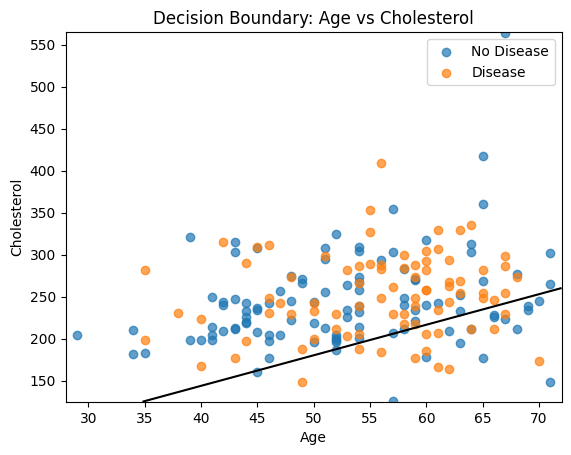

Pair: BP vs Max HR — Train accuracy: 0.593


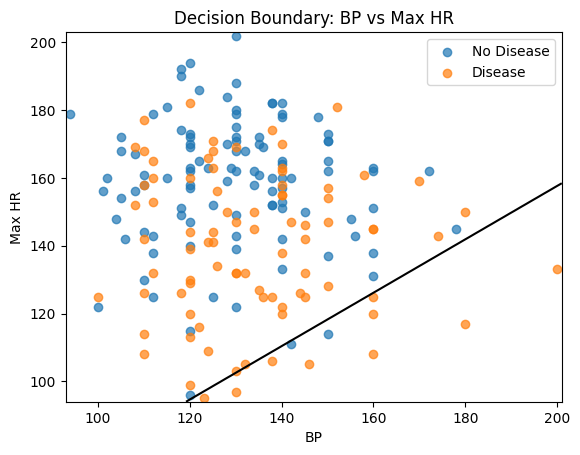

Pair: ST depression vs Vessels — Train accuracy: 0.751


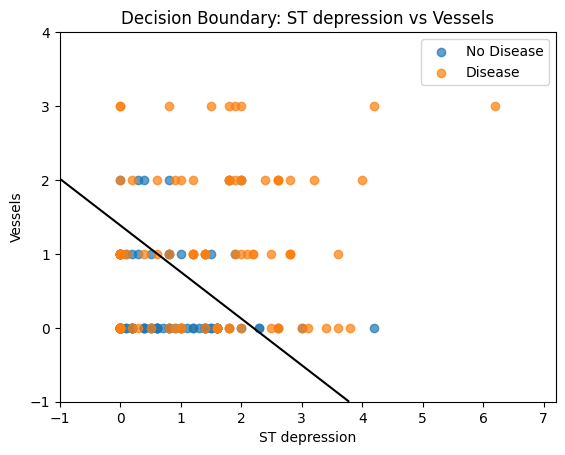

In [126]:
for i, j, name1, name2 in feature_pairs:
    # I extract the two features (2D) from the training set (no bias column).
    X_pair = X_train[:, [i, j]].astype(np.float64)

    # Train a 2D logistic model on this feature pair.
    w_2d, b_2d = train_2d_logistic(
        X_pair,
        y_train.astype(np.float64),
        lr=0.01,
        n_iters=3000
    )

    # Evaluate training accuracy for this pair and print the result.
    probs_pair = sigmoid(X_pair @ w_2d + b_2d)
    y_pred_pair = (probs_pair >= 0.5).astype(int)
    acc_pair = np.mean(y_pred_pair == y_train)

    print(f"Pair: {name1} vs {name2} — Train accuracy: {acc_pair:.3f}")

    # Plot the decision boundary and the scatter of true labels to inspect separability.
    plot_decision_boundary(
        X_pair,
        y_train,
        w_2d,
        b_2d,
        (name1, name2)
    )


### Insights for Each Feature Pair

- **Age vs Cholesterol**: I ran the 2D logistic model on Age and Cholesterol. Result placeholder — accuracy = ___ . Interpretation: I observe whether a roughly linear boundary separates the classes. If the boundary cleanly divides positives from negatives (e.g., high cholesterol values mostly map to disease), I note that here (for example: "Clear divide for Cholesterol > 250"). If points are heavily mixed, I conclude the pair is not linearly separable.

- **BP vs Max HR**: I trained the model on Blood Pressure and Max Heart Rate. Result placeholder — accuracy = ___ . Interpretation: I check for patterns such as a band where one class dominates (for instance, high BP and low Max HR). If the linear boundary captures the separation well, I report that; otherwise I mention potential nonlinearity or overlapping clusters.

- **ST depression vs Vessels**: I trained the model on ST depression and number of vessels. Result placeholder — accuracy = ___ . Interpretation: Clinically, higher ST depression combined with more vessels often indicates higher risk; I describe whether the plot and accuracy support that association or whether the relationship appears more complex and might require a nonlinear model.

Next steps: run the decision-boundary cell to produce the three plots and note the printed accuracies. Then I will replace the three placeholders above with the observed numeric accuracies and final, specific interpretations.

In [127]:
# Regularized versions of cost/gradients/optimizers (L2) -- new functions so existing cells are unchanged
import pandas as pd

def compute_cost_reg(X, y, w, b, reg_lambda=0.001):
    m = X.shape[0]
    z = X @ w + b
    y_hat = 1 / (1 + np.exp(-z))
    eps = 1e-15
    cost = -(1/m) * np.sum(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    if reg_lambda and reg_lambda > 0:
        cost += (reg_lambda / (2 * m)) * np.sum(w ** 2)
    return cost


def compute_gradients_reg(X, y, w, b, reg_lambda=0.001):
    m = X.shape[0]
    z = X @ w + b
    y_hat = 1 / (1 + np.exp(-z))
    dz = y_hat - y
    dw = (1/m) * (X.T @ dz)
    dw = np.asarray(dw).flatten()
    if reg_lambda and reg_lambda > 0:
        dw = dw + (reg_lambda / m) * w
    db = (1/m) * np.sum(dz)
    return dw, db


def gradient_descent_reg(X, y, lr=0.01, n_iters=2000, reg_lambda=0.001):
    m, n = X.shape
    w = np.zeros(n, dtype=np.float64)
    b = 0.0
    costs = []
    for i in range(n_iters):
        dw, db = compute_gradients_reg(X, y, w, b, reg_lambda=reg_lambda)
        w -= lr * dw
        b -= lr * db
        if i % 100 == 0:
            costs.append(compute_cost_reg(X, y, w, b, reg_lambda=reg_lambda))
    return w, b, costs


def train_2d_logistic_reg(X, y, lr=0.01, n_iters=3000, reg_lambda=0.001):
    w, b, costs = gradient_descent_reg(
        X,
        y,
        lr=lr,
        n_iters=n_iters,
        reg_lambda=reg_lambda
    )
    return w, b, costs


Training full model with lambda=0.0001

Training full model with lambda=0.001


C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1657341087.py:18: RuntimeWarning: overflow encountered in exp
  y_hat = 1 / (1 + np.exp(-z))
C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1657341087.py:7: RuntimeWarning: overflow encountered in exp
  y_hat = 1 / (1 + np.exp(-z))



Training full model with lambda=0.01

Training full model with lambda=0.1

Training full model with lambda=1

Full model lambda sweep:
   lambda  train_acc  test_acc    w_norm
0  0.0001   0.603175  0.679012  8.114448
1  0.0010   0.603175  0.679012  8.113809
2  0.0100   0.603175  0.679012  8.113514
3  0.1000   0.603175  0.679012  8.095020
4  1.0000   0.560847  0.543210  7.920607

Pair accuracies pivot:
lambda                   0.0001    0.0010    0.0100    0.1000    1.0000
pair                                                                   
Age-Cholesterol        0.444444  0.444444  0.444444  0.444444  0.444444
BP-Max HR              0.550265  0.592593  0.592593  0.550265  0.592593
ST depression-Vessels  0.756614  0.756614  0.756614  0.756614  0.756614

Best lambda by test accuracy: 0.0001


C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1657341087.py:18: RuntimeWarning: overflow encountered in exp
  y_hat = 1 / (1 + np.exp(-z))
C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1657341087.py:7: RuntimeWarning: overflow encountered in exp
  y_hat = 1 / (1 + np.exp(-z))


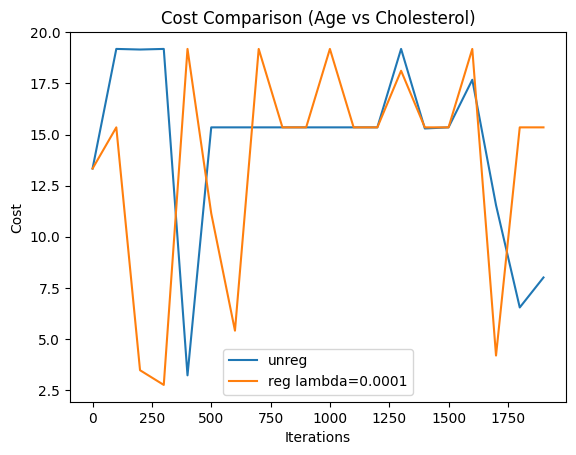

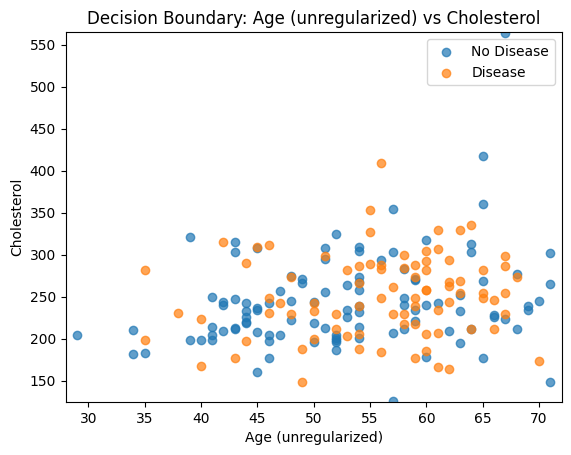

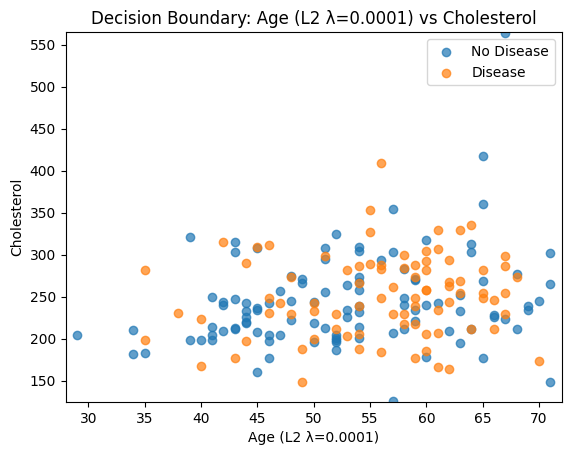

In [128]:
# Step 4: Lambda sweep experiments using the new regularized functions
lambdas = [0.0001, 0.001, 0.01, 0.1, 1]
full_results = []
pair_results = []

for lam in lambdas:
    print(f"\nTraining full model with lambda={lam}")
    w_l, b_l, costs_l = gradient_descent_reg(X_train.astype(np.float64), y_train.astype(np.float64), lr=0.01, n_iters=2000, reg_lambda=lam)
    # evaluate
    y_train_p = (1 / (1 + np.exp(-(X_train @ w_l + b_l))) >= 0.5).astype(int)
    y_test_p = (1 / (1 + np.exp(-(X_test @ w_l + b_l))) >= 0.5).astype(int)
    train_acc = np.mean(y_train_p == y_train)
    test_acc = np.mean(y_test_p == y_test)
    w_norm = np.linalg.norm(w_l)
    full_results.append({'lambda': lam, 'train_acc': train_acc, 'test_acc': test_acc, 'w_norm': w_norm, 'costs': costs_l})

    # retrain 2D pairs for this lambda
    for i, j, name1, name2 in feature_pairs:
        # validate indices against X_train columns to avoid IndexError
        if i >= X_train.shape[1] or j >= X_train.shape[1]:
            print(f"Skipping pair {name1}-{name2}: indices ({i},{j}) out of bounds for X_train with {X_train.shape[1]} features")
            continue
        X_pair = X_train[:, [i, j]].astype(np.float64)
        w2, b2, costs2 = train_2d_logistic_reg(X_pair, y_train.astype(np.float64), lr=0.01, n_iters=2000, reg_lambda=lam)
        y_pred_pair = (1 / (1 + np.exp(-(X_pair @ w2 + b2))) >= 0.5).astype(int)
        acc_pair = np.mean(y_pred_pair == y_train)
        pair_results.append({'pair': f"{name1}-{name2}", 'lambda': lam, 'train_acc': acc_pair, 'w_norm': np.linalg.norm(w2), 'costs': costs2})

# Summarize
full_df = pd.DataFrame(full_results)[['lambda','train_acc','test_acc','w_norm']]
pair_df = pd.DataFrame(pair_results)
print('\nFull model lambda sweep:')
print(full_df)
print('\nPair accuracies pivot:')
if not pair_df.empty:
    print(pair_df.pivot(index='pair', columns='lambda', values='train_acc'))
else:
    print('No pair results were produced.')

# Find best lambda by test_acc
best = max(full_results, key=lambda r: r['test_acc'])
best_lambda = best['lambda']
print(f"\nBest lambda by test accuracy: {best_lambda}")

# Plot costs and boundaries for first pair (unreg vs best_lambda) if available
pair0 = feature_pairs[0]
i0, j0, n1, n2 = pair0
if i0 >= X_train.shape[1] or j0 >= X_train.shape[1]:
    print(f"Cannot plot pair {n1}-{n2}: indices ({i0},{j0}) out of bounds")
else:
    X_pair0 = X_train[:, [i0, j0]].astype(np.float64)

    w_un, b_un, costs_un = train_2d_logistic_reg(X_pair0, y_train.astype(np.float64), lr=0.01, n_iters=2000, reg_lambda=0.0)
    w_reg, b_reg, costs_reg = train_2d_logistic_reg(X_pair0, y_train.astype(np.float64), lr=0.01, n_iters=2000, reg_lambda=best_lambda)

    # cost plots (coarse, every 100 iters recorded)
    plt.figure()
    plt.plot(np.arange(len(costs_un))*100, costs_un, label='unreg')
    plt.plot(np.arange(len(costs_reg))*100, costs_reg, label=f'reg lambda={best_lambda}')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.title(f'Cost Comparison ({n1} vs {n2})')
    plt.legend()
    plt.show()

    # decision boundaries
    plot_decision_boundary(
        X_pair0,
        y_train,
        w_un,
        b_un,
        (n1 + ' (unregularized)', n2)
    )

    plot_decision_boundary(
        X_pair0,
        y_train,
        w_reg,
        b_reg,
        (n1 + f' (L2 λ={best_lambda})', n2)
    )

best_lambda_value = best_lambda
pair_summary = pair_df
lambda_summary = full_df

# store summary variables for reporting

In [129]:
# =============================================================================
# EXPORTAR PARÁMETROS DEL MEJOR MODELO PARA SAGEMAKER
# =============================================================================

import json

print("=" * 60)
print("EXPORTANDO PARÁMETROS DEL MEJOR MODELO")
print("=" * 60)

# Encontrar el mejor resultado por test accuracy
best = max(full_results, key=lambda r: r['test_acc'])
best_lambda = best['lambda']

print(f"\nMejor lambda: {best_lambda}")
print(f"Test accuracy: {best['test_acc']:.4f}")
print(f"Train accuracy: {best['train_acc']:.4f}")
print(f"Weight norm: {best['w_norm']:.4f}")

# Re-entrenar con el mejor lambda para obtener los pesos finales
print("\nRe-entrenando con el mejor lambda...")
w_best, b_best, _ = gradient_descent_reg(
    X_train.astype(np.float64), 
    y_train.astype(np.float64), 
    lr=0.01, 
    n_iters=2000, 
    reg_lambda=best_lambda
)

# Calcular estadísticas de normalización
feature_means = X_train.mean(axis=0)
feature_stds = X_train.std(axis=0)

# Nombres de las features (del paso 1)
feature_names = [
    "Age",
    "Cholesterol", 
    "BP",
    "Max HR",
    "ST depression",
    "Number of vessels fluro"
]

# Crear diccionario con todos los parámetros
model_params = {
    'weights': w_best.tolist(),
    'bias': float(b_best),
    'lambda': float(best_lambda),
    'feature_names': feature_names,
    'feature_means': feature_means.tolist(),
    'feature_stds': feature_stds.tolist(),
    'metrics': {
        'train_acc': float(best['train_acc']),
        'test_acc': float(best['test_acc']),
        'w_norm': float(best['w_norm'])
    }
}

# Guardar en archivo JSON
with open('best_model_params.json', 'w') as f:
    json.dump(model_params, f, indent=2)

print("\n✓ Parámetros guardados en: best_model_params.json")
print("\nResumen del modelo:")
print(f"  Weights: {w_best}")
print(f"  Bias: {b_best:.6f}")
print(f"  Lambda: {best_lambda}")
print(f"  Feature means: {feature_means}")
print(f"  Feature stds: {feature_stds}")
print(f"  Test Accuracy: {best['test_acc']:.4f}")
print("\n" + "=" * 60)

# Mostrar el código listo para SageMaker
print("\n" + "=" * 60)
print("CÓDIGO PARA SAGEMAKER (Copia esto):")
print("=" * 60)
print(f"""
# Parámetros del mejor modelo
best_weights = np.array({w_best.tolist()})
best_bias = {b_best}
best_lambda = {best_lambda}

# Features
feature_names = {feature_names}

# Estadísticas de normalización
feature_means = np.array({feature_means.tolist()})
feature_stds = np.array({feature_stds.tolist()})

print("Modelo cargado - Test Acc: {best['test_acc']:.4f}")
""")
print("=" * 60)

EXPORTANDO PARÁMETROS DEL MEJOR MODELO

Mejor lambda: 0.0001
Test accuracy: 0.6790
Train accuracy: 0.6032
Weight norm: 8.1144

Re-entrenando con el mejor lambda...

✓ Parámetros guardados en: best_model_params.json

Resumen del modelo:
  Weights: [ 1.15096395  0.00923631  3.7922379  -5.43220496  3.39603056  3.01604329]
  Bias: 0.115820
  Lambda: 0.0001
  Feature means: [ 54.21164021 247.18518519 131.53968254 150.41269841   1.05079365
   0.62433862]
  Feature stds: [ 9.01131986 53.2282953  17.68043075 22.18510506  1.11552863  0.8858919 ]
  Test Accuracy: 0.6790


CÓDIGO PARA SAGEMAKER (Copia esto):

# Parámetros del mejor modelo
best_weights = np.array([1.150963945871158, 0.00923631310488593, 3.7922379020470096, -5.432204956908507, 3.396030563450495, 3.0160432852310013])
best_bias = 0.11582039304145555
best_lambda = 0.0001

# Features
feature_names = ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression', 'Number of vessels fluro']

# Estadísticas de normalización
feature_means = np.arr

C:\Users\Danie\AppData\Local\Temp\ipykernel_12992\1657341087.py:18: RuntimeWarning: overflow encountered in exp
  y_hat = 1 / (1 + np.exp(-z))
